  featurecla  scalerank  min_zoom  \
0       Land        0.0       0.0   
1       Land        6.0       5.0   
2       Land        5.0       3.0   
3       Land        6.0       6.0   
4       Land        5.0       4.0   

                                            geometry  
0  MULTIPOLYGON (((-0.00029 -71.49903, 0.01555 -7...  
1  MULTIPOLYGON (((166.13697 -50.86435, 166.20525...  
2  MULTIPOLYGON (((-78.78897 -33.60906, -78.78038...  
3  MULTIPOLYGON (((163.98512 -20.04762, 163.98609...  
4  MULTIPOLYGON (((134.70737 -6.58904, 134.72006 ...  


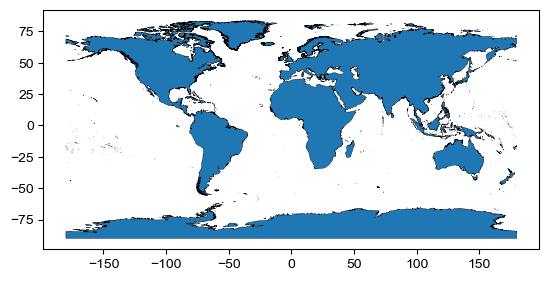

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

# 这个API已经被废弃了
# fn = gpd.datasets.get_path("naturalearth_cities")
# print(fn)
fn = '/Users/tanzhenyu/Dataware/GeoPy/natural_earth_vector.gpkg'
world = gpd.read_file(fn, layer='ne_10m_land')

print(world.head())

world.plot(
    linewidth=0.25,      # 边界线宽
    edgecolor='black',  # 边界线颜色
)
plt.savefig('/Users/tanzhenyu/Desktop/图7.2.png', dpi=600)

In [8]:
import pandas as pd

df = pd.read_csv(r"C:\Users\tanzhenyu\Dataware\GeoPy\DataForBook\CitiyPopulation.csv", delimiter=',')
# 去掉第一列序号列，name和country列读取为DataFrame以后类型为object，转为str
df = df.drop(columns=['rank'])
df[['name', 'country']] = df[['name', 'country']].apply(str)

gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.longitude, df.latitude)
)

gdf.to_file('CitiyPopulation.shp')

C:\Users\tanzhenyu\AppData\Local\Temp\ipykernel_5536\3326466599.py:12: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('CitiyPopulation.shp')


   0                        geometry  Blue  Green  Red  NIR
0  0  POINT (287866.000 3731395.000)     0      0    0    0
1  1  POINT (381643.000 3813204.000)     0      0    0    0
6  6  POINT (216231.000 3821688.000)     0      0    0    0
8  8  POINT (208840.000 3782275.000)     0      0    0    0


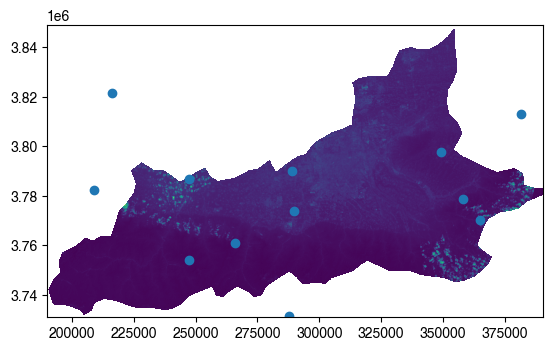

In [29]:
import numpy as np
import geopandas as gpd
import rasterio
import random
import matplotlib.pyplot as plt
from rasterio.plot import show
from shapely.geometry import Point


# 打开栅格数据
fn = r"C:\Users\tanzhenyu\Dataware\GeoPy\DataForBook\XiAn\XiAn-202108-AOI.tif"
with rasterio.open(fn) as src:
    extent=[src.bounds[0], src.bounds[2], src.bounds[1], src.bounds[3]]

    # 随机在数据所在的空间范围内产生10个样点
    count = 12
    points = [Point(random.randint(int(extent[0]), int(extent[1])),
                    random.randint(int(extent[2]), int(extent[3]))) for _ in range(count)]
    gdf = gpd.GeoDataFrame([i for i in range(count)], geometry=points, crs=32630)
    gdf.head()

    fig, ax = plt.subplots()
    # Rasterio会自动帮我们完成投影坐标到图上坐标的转化
    ax = rasterio.plot.show(src, extent=extent, ax=ax)
    gdf.plot(ax=ax)

    coord_list = [(x,y) for x,y in zip(gdf['geometry'].x , gdf['geometry'].y)]
    # 结果为一个list，list中的元素类型为array，array中包含的是四个波段的像素值
    values = [x for x in src.sample(coord_list)]
    # 将list转为pandas，并重命名列
    values = pd.DataFrame(list(map(np.ravel, values)))
    values.columns = ['Blue', 'Green', 'Red', 'NIR']
    # 将其与原来的点数据对应的GeoDataFrame拼接起来
    result = pd.concat((gdf, values), axis=1)
    # 如果某行结果都是0元素，则说明该点落在了研究区之外，则将其删除
    result = result[result['Blue'] + result['Green'] + result['NIR'] <= 0]
    print(result)